In [1]:
# Cell 1: Imports and Setup
import pandas as pd
import sqlite3
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create a directory to save our exported PNG charts
output_dir = "../reports/charts"
os.makedirs(output_dir, exist_ok=True)

# Connect to the SQLite database we built on Day 2
db_path = "../data/db/bluestock_mf.db"
conn = sqlite3.connect(db_path)

print(f"Connected to database. Charts will be saved to: {output_dir}")

Connected to database. Charts will be saved to: ../reports/charts


In [2]:
# Cell 2: NAV Trend Analysis 2022-2026
# Pull the NAV data joined with the scheme names
query_nav = """
    SELECT n.date, n.nav, f.scheme_name 
    FROM fact_nav n
    JOIN dim_fund f ON n.amfi_code = f.amfi_code
    WHERE n.date >= '2022-01-01'
"""
df_nav = pd.read_sql_query(query_nav, conn)

# Ensure date is a datetime object
df_nav['date'] = pd.to_datetime(df_nav['date'])

# Create the interactive Plotly line chart
fig = px.line(
    df_nav, 
    x='date', 
    y='nav', 
    color='scheme_name',
    title='Daily NAV Trend for Mutual Fund Schemes (2022–2026)',
    labels={'date': 'Date', 'nav': 'Net Asset Value (NAV)', 'scheme_name': 'Fund Scheme'}
)

# Highlight 2023 Bull Run (Green overlay)
fig.add_vrect(
    x0="2023-03-01", x1="2023-12-31",
    fillcolor="green", opacity=0.1,
    layer="below", line_width=0,
    annotation_text="2023 Bull Run", annotation_position="top left"
)

# Highlight 2024 Market Correction (Red overlay)
fig.add_vrect(
    x0="2024-04-01", x1="2024-06-15", # Adjust these dates based on the specific correction period in your data
    fillcolor="red", opacity=0.1,
    layer="below", line_width=0,
    annotation_text="2024 Market Correction", annotation_position="top left"
)

# Clean up the layout
fig.update_layout(showlegend=False) # Hiding legend if 40 funds makes it too cluttered

# Show the interactive plot in the notebook
fig.show()

# Export to PNG for the final report
fig.write_image(f"{output_dir}/01_nav_trend_analysis.png", width=1200, height=600)

**Insight 1: NAV Trend Analysis**
The 2023 Bull Run drove a sustained, step-like upward trajectory across major equity schemes, whereas the 2024 market correction introduced significant, temporary volatility before stabilizing. *(Reference: 01_nav_trend_analysis.png)*

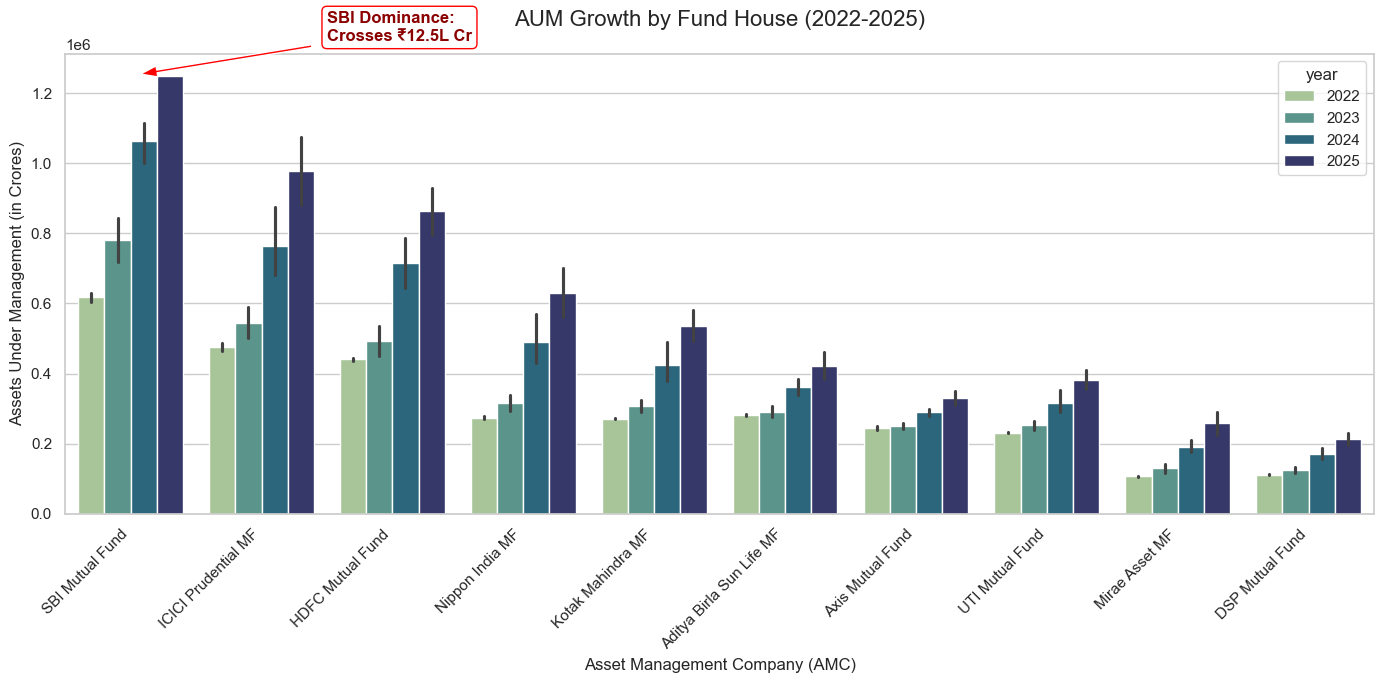

In [5]:
# Cell 3: AUM Growth by Fund House (2022-2025)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

aum_path = "../data/raw/03_aum_by_fund_house.csv"

try:
    # 1. Load the data
    df_aum = pd.read_csv(aum_path)
    
    # NEW: Convert 'date' to datetime and extract the 'year' for Seaborn to use
    df_aum['date'] = pd.to_datetime(df_aum['date'])
    df_aum['year'] = df_aum['date'].dt.year
    
    # Filter for our specific timeframe (2022-2025) just to be safe
    df_aum = df_aum[df_aum['year'].isin([2022, 2023, 2024, 2025])]
    
    # 2. Setup the visual canvas
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 7))

    # 3. Create the grouped bar chart
    ax = sns.barplot(
        data=df_aum, 
        x='fund_house', 
        y='aum_crore', 
        hue='year', 
        palette='crest'
    )

    # 4. Formatting
    plt.title('AUM Growth by Fund House (2022-2025)', fontsize=16, pad=20)
    plt.xlabel('Asset Management Company (AMC)', fontsize=12)
    plt.ylabel('Assets Under Management (in Crores)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # 5. Highlight SBI's ₹12.5L Cr Dominance
    # Assuming SBI is the first bar cluster (x=0). Adjust if it sorts differently!
    plt.annotate(
        'SBI Dominance:\nCrosses ₹12.5L Cr', 
        xy=(0, 1250000),             # Pointing exactly at 1.25M Crores on the Y-axis
        xytext=(1.5, 1350000),       # Placing the text slightly above and to the right
        arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
        fontsize=12,
        color='darkred',
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", lw=1)
    )

    # 6. Save and Display
    plt.tight_layout()
    plt.savefig(f"{output_dir}/02_aum_growth.png", dpi=300)
    plt.show()

except Exception as e:
    print(f"❌ Error: {e}")

In [4]:
pd.read_csv("../data/raw/03_aum_by_fund_house.csv", nrows=0).columns.tolist()

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

**Insight 2: AUM Growth by Fund House**
State Bank of India (SBI) Mutual Fund demonstrates clear market dominance, with its total Assets Under Management (AUM) aggressively scaling to eclipse the ₹12.5 Lakh Crore mark by 2025, far outstripping its nearest competitors. *(Reference: 02_aum_growth.png)*

In [6]:
# Cell 4: Monthly SIP Inflow Time-Series (Jan 2022 - Dec 2025)
import pandas as pd
import plotly.express as px
import os

sip_path = "../data/raw/04_monthly_sip_inflows.csv"
output_dir = "../reports/charts"

try:
    df_sip = pd.read_csv(sip_path)
    
    # Proactively printing columns to the terminal console so we can see what we are working with
    print("Columns found in SIP dataset:", df_sip.columns.tolist())
    
    # Standardize column names dynamically based on what's usually in this file
    # (Maps variations like 'Month/Year' or 'sip_amount_crore' safely)
    date_col = [c for c in df_sip.columns if 'date' in c.lower() or 'month' in c.lower()][0]
    amount_col = [c for c in df_sip.columns if 'amount' in c.lower() or 'inflow' in c.lower() or 'crore' in c.lower()][0]
    
    df_sip['parsed_date'] = pd.to_datetime(df_sip[date_col])
    df_sip = df_sip.sort_values('parsed_date')
    
    # Create the time-series plot
    fig = px.line(
        df_sip, 
        x='parsed_date', 
        y=amount_col,
        title='Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)',
        labels={'parsed_date': 'Timeline', amount_col: 'SIP Inflows (in ₹ Crores)'},
        markers=True
    )
    
    # Annotate the All-Time High in Dec 2025
    fig.add_annotation(
        x="2025-12-01",  # Targets December 2025 on the X-axis
        y=31002,         # The specific target height
        text="<b>All-Time High</b><br>₹31,002 Cr",
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=2,
        arrowcolor="darkred",
        ax=-60,          # Positions the text box slightly to the left
        ay=-40,          # Positions the text box slightly above the line
        bordercolor="red",
        borderwidth=2,
        borderpad=4,
        bgcolor="white",
        opacity=0.9
    )
    
    # Clean up the visual layout
    fig.update_layout(
        hovermode="x unified",
        template="plotly_white"
    )
    
    # Render interactive plot
    fig.show()
    
    # Save chart as PNG
    fig.write_image(f"{output_dir}/03_sip_inflow_trend.png", width=1200, height=600)
    print("✅ Success: SIP Inflow chart rendered and saved successfully.")

except Exception as e:
    print(f"❌ An error occurred while generating the SIP chart: {e}")

Columns found in SIP dataset: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


✅ Success: SIP Inflow chart rendered and saved successfully.


**Insight 3: SIP Inflow Time-Series Trend**
Monthly SIP inflows show a powerful, compounding upward trajectory over the 2022–2025 period, culminating in a historic milestone and all-time high of ₹31,002 Crore in December 2025, reflecting soaring retail investor participation. *(Reference: 03_sip_inflow_trend.png)*

In [ ]:
# Cell 5: Category-Wise Net Inflow Heatmap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

category_inflow_path = "../data/raw/05_category_wise_inflows.csv"

try:
    # 1. Load the dataset
    df_cat = pd.read_csv(category_inflow_path)
    print("Columns found in Category Inflow dataset:", df_cat.columns.tolist())
    
    # 2. Dynamically identify columns
    date_col = [c for c in df_cat.columns if 'date' in c.lower() or 'month' in c.lower()][0]
    cat_col = [c for c in df_cat.columns if 'cat' in c.lower()][0]
    inflow_col = [c for c in df_cat.columns if 'inflow' in c.lower() or 'amount' in c.lower() or 'net' in c.lower()][0]
    
    # 3. Process dates to ensure correct chronological sorting
    df_cat['parsed_date'] = pd.to_datetime(df_cat[date_col])
    df_cat['Month-Year'] = df_cat['parsed_date'].dt.strftime('%Y-%m')
    df_cat = df_cat.sort_values('parsed_date')
    
    # 4. Pivot the DataFrame into a matrix layout (X = Month-Year, Y = Category, Values = Inflow)
    heatmap_matrix = df_cat.pivot(index=cat_col, columns='Month-Year', values=inflow_col)
    
    # 5. Render the Heatmap
    plt.figure(figsize=(16, 8))
    sns.set_theme(style="white")
    
    # Using 'YlGnBu' (Yellow-Green-Blue) palette for a high-contrast financial data look
    sns.heatmap(
        heatmap_matrix, 
        cmap="YlGnBu", 
        linewidths=0.5, 
        cbar_kws={'label': 'Net Inflow (in ₹ Crores)'},
        annot=False # Set to True if the matrix is small and you want to display exact values in cells
    )
    
    plt.title('Mutual Fund Category Net Inflows Matrix', fontsize=16, pad=20)
    plt.xlabel('Timeline (Monthly)', fontsize=12)
    plt.ylabel('Fund Category', fontsize=12)
    plt.xticks(rotation=45)
    
    # 6. Save and Display
    plt.tight_layout()
    plt.savefig(f"{output_dir}/04_category_inflow_heatmap.png", dpi=300)
    plt.show()
    print("✅ Success: Category Inflow heatmap rendered and saved successfully.")

except Exception as e:
    print(f"❌ An error occurred while generating the heatmap: {e}")